# Polynomial Regression and Overfitting

This notebook demonstrates overfitting in polynomial regression and how Lasso regularization helps:
1. Generating synthetic quadratic data with controlled noise
2. Splitting data into training and test sets
3. Fitting polynomial models of increasing complexity (degrees 1–14)
4. Comparing standard Linear Regression vs Lasso regularization
5. Analyzing overfitting through training and testing error visualization

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso

## Generate Synthetic Data

The true relationship is $y = 2 + 3x - 0.5x^2$. Gaussian noise is added to simulate real-world measurements.

In [2]:
np.random.seed(42)

x = np.linspace(0, 10, 40)
y_true = 2 + 3*x - 0.5*x**2
noise_level = 5
y_noisy = y_true + np.random.normal(0, noise_level, size=len(x))

X_train, X_test, y_train, y_test = train_test_split(x, y_noisy, test_size=0.3, random_state=42)

## Visualize the Data

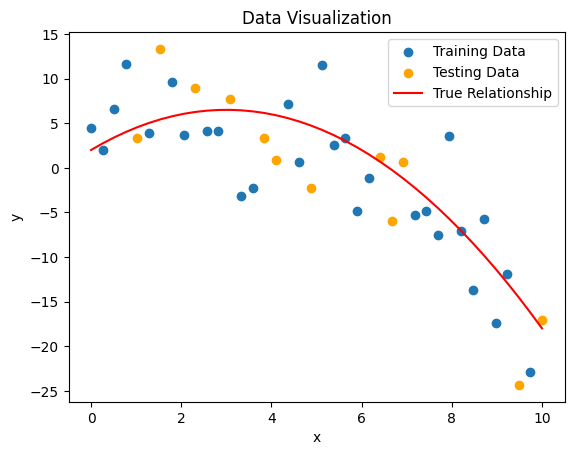

In [3]:
plt.scatter(X_train, y_train, label='Training Data')
plt.scatter(X_test, y_test, label='Testing Data', color='orange')
plt.plot(x, y_true, label='True Relationship', color='red')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Data Visualization')
plt.legend()
plt.show()

## Fit Polynomial Models of Increasing Degree

For each degree, polynomial features are created using the Vandermonde matrix. Both a plain `LinearRegression` and a `Lasso` (alpha=1) model are fitted and their MSE recorded.

c:\Users\Riccardo\miniconda3\envs\data-science\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.336e+02, tolerance: 1.931e-01
  model = cd_fast.enet_coordinate_descent(
c:\Users\Riccardo\miniconda3\envs\data-science\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.875e+02, tolerance: 1.931e-01
  model = cd_fast.enet_coordinate_descent(
c:\Users\Riccardo\miniconda3\envs\data-science\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or co

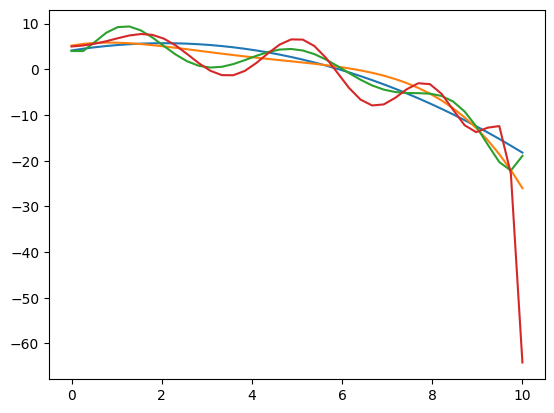

In [4]:
degrees = range(1, 15)

linear_train_errors = []
linear_test_errors = []
lasso_train_errors = []
lasso_test_errors = []

for degree in degrees:
    X_train_poly = np.vander(X_train, degree + 1, increasing=True)
    X_test_poly  = np.vander(X_test,  degree + 1, increasing=True)

    model       = LinearRegression()
    model_lasso = Lasso(alpha=1, max_iter=10000)

    model.fit(X_train_poly, y_train)
    model_lasso.fit(X_train_poly, y_train)

    y_train_pred = model.predict(X_train_poly)
    y_test_pred  = model.predict(X_test_poly)
    linear_train_errors.append(np.mean((y_train - y_train_pred) ** 2))
    linear_test_errors.append(np.mean((y_test - y_test_pred) ** 2))

    if degree in [2, 4, 8, 14]:
        plot_y = model.predict(np.vander(x, degree + 1, increasing=True))
        plt.plot(x, plot_y, label=f'Degree {degree}')

    y_train_pred = model_lasso.predict(X_train_poly)
    y_test_pred  = model_lasso.predict(X_test_poly)
    lasso_train_errors.append(np.mean((y_train - y_train_pred) ** 2))
    lasso_test_errors.append(np.mean((y_test - y_test_pred) ** 2))

## Visualize Fitted Curves

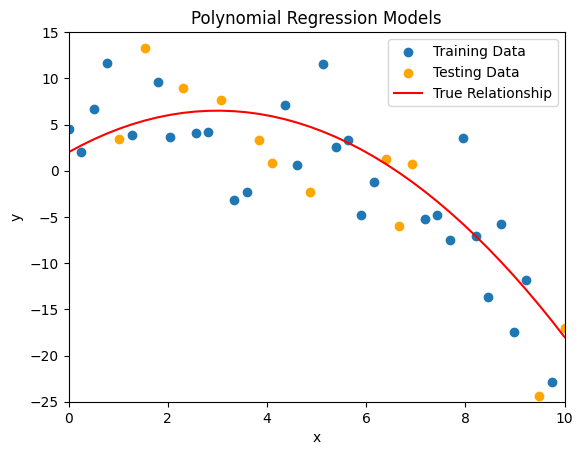

In [5]:
plt.xlim(0, 10)
plt.ylim(-25, 15)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Polynomial Regression Models')
plt.scatter(X_train, y_train, label='Training Data')
plt.scatter(X_test, y_test, label='Testing Data', color='orange')
plt.plot(x, y_true, label='True Relationship', color='red')
plt.legend()
plt.show()

## Training vs Testing Error

The log-scale plot reveals where overfitting starts: training error keeps decreasing while test error rises. Lasso regularization dampens this effect.

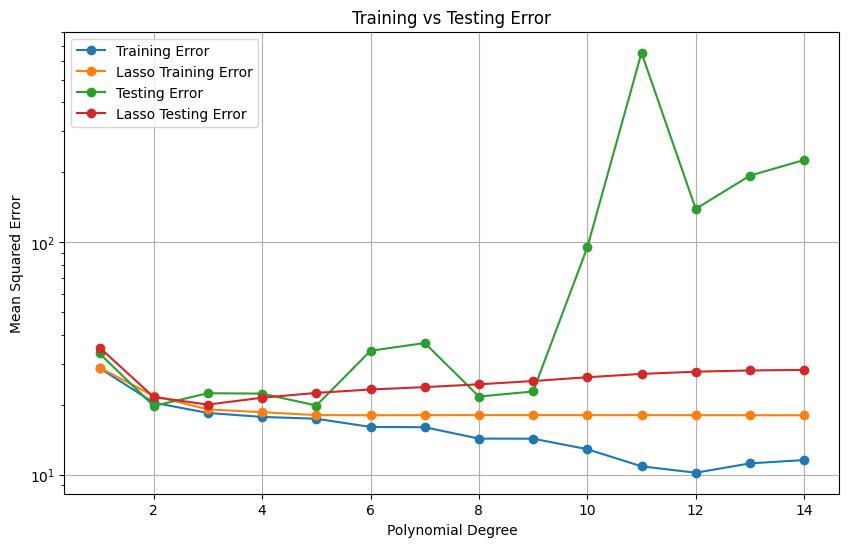

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(degrees, linear_train_errors, label='Training Error', marker='o')
plt.plot(degrees, lasso_train_errors,  label='Lasso Training Error', marker='o')
plt.plot(degrees, linear_test_errors,  label='Testing Error', marker='o')
plt.plot(degrees, lasso_test_errors,   label='Lasso Testing Error', marker='o')
plt.xlabel('Polynomial Degree')
plt.ylabel('Mean Squared Error')
plt.title('Training vs Testing Error')
plt.legend()
plt.yscale('log')
plt.grid(True)
plt.show()